In [1]:
import numpy as np
import pandas as pd
from caveclient import CAVEclient
from meshparty.skeleton import Skeleton
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def denoise_segs(segs):
    #Goes through with a rolling window of 5.
    
    segs_denoise = []

    for i in range(len(segs)):
        temp = segs[i]
        temp['myelin'] = np.where(temp['myelin'] == -1, 0.5, temp['myelin']) #set error entries to 0.5
        temp['myelin'] = np.concatenate(([0], [0], temp['myelin'], [0], [0])) #pad with two zeros on each side
        temp['myelin'] = pd.Series(temp['myelin']).rolling(window=5, center=True).mean().to_numpy() #apply rolling mean with window of 5
        temp['myelin'] = np.where(temp['myelin'] >= 0.5, 1, 0) #threshold at 0.5
        temp['myelin'] = temp['myelin'][2:-2] #remove padding
        segs_denoise.append(temp)
    return segs_denoise

def get_total_myelin_length(segs):
    total_length = 0
    for seg in segs:
        positions = np.array(seg['pt_position'])
        myelin_flags = np.array(seg['myelin'])
        for i in range(len(positions) - 1):
            if myelin_flags[i] == 1 and myelin_flags[i + 1] == 1:
                p1 = positions[i] * np.array([4, 4, 40])  # Convert back to nm
                p2 = positions[i + 1] * np.array([4, 4, 40])
                length = np.linalg.norm(p2 - p1)
                total_length += length
    return total_length
    

In [3]:
client = CAVEclient('minnie65_public')
client.version = 1507

cell_type_df = client.materialize.query_table('aibs_metamodel_celltypes_v661')

In [4]:
pt_root_id = 864691136137140093
cell_type = cell_type_df[cell_type_df['pt_root_id'] == pt_root_id]['cell_type'].values[0]
print(cell_type)

5P-ET


In [77]:
#Create a myelin info dataframe.

directory = 'segments_myelin_1507'


myelin_info_df = pd.DataFrame(columns=['pt_root_id', 'total_myelin_length','cell_type', 'number_of_segments'])

for filename in os.listdir(directory):
    if filename.endswith('.pkl'):
        pt_root_id = int(filename.split('.')[0])
        print(pt_root_id)
        
        with open(os.path.join(directory, filename), 'rb') as f:
            segs = pickle.load(f)
        segs_denoised = denoise_segs(segs)
        total_myelin_length = get_total_myelin_length(segs_denoised)/1000 #convert to microns 
        total_myelin_length = round(total_myelin_length, 2)  #round to 2 decimal places
        # cell_type = cell_type_df[cell_type_df['pt_root_id'] == pt_root_id]['cell_type'].values[0]
        #if cell type not found, set to unknown
        if len(cell_type_df[cell_type_df['pt_root_id'] == pt_root_id]) == 0:
            cell_type = 'unknown'
        else:
            cell_type = cell_type_df[cell_type_df['pt_root_id'] == pt_root_id]['cell_type'].values[0]
        number_of_segments = len(segs_denoised)

        myelin_info_df = pd.concat([
            myelin_info_df,
            pd.DataFrame([{
                'pt_root_id': pt_root_id,
                'total_myelin_length': total_myelin_length,
                'cell_type': cell_type
                ,'number_of_segments': number_of_segments
                
            }])
        ], ignore_index=True)

864691135938604804
864691136578982164
864691136196131542
864691135572346349
864691135699487522


/var/folders/qp/r9cmw1dn5sl3gwgf322l1ykr0000gn/T/ipykernel_420/2028299864.py:26: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  myelin_info_df = pd.concat([


864691135356753871
864691135258083503
864691135928938196
864691135274038801
864691135256861871
864691135325071004
864691136674080135
864691136034011579
864691135447638356
864691135273655569
864691135294935564
864691135891467401
864691135773910603
864691136053374451
864691135339982310
864691136108071129
864691135656410306
864691135526405723
864691135878061395
864691135473692722
864691136664845278
864691135502748482
864691135777521837
864691136674783111
864691135474179378
864691135105879117
864691136144674612
864691136040977662
864691135614771147
864691136335553971
864691137199419457
864691135066631492
864691135878154067
864691136053437683
864691135464714565
864691136578820884
864691135155894884
864691136579127060
864691136953835487
864691135866558078
864691135464263742
864691135430356784
864691135479830982
864691135801604706
864691136380757461
864691135476495936
864691135082864887
864691135517376211
864691135361314119
864691136521831825
864691135137007129
864691136137140093
864691135346

In [ ]:
#Show all entries by cell type

# myelin_info_df.loc[0:50] 
# print all entries where cell type is BC 
myelin_info_df[myelin_info_df['cell_type'] == '23P']

# myelin_info_df[myelin_info_df['pt_root_id'] == 864691135566237527]

#pickle myelin info df
# with open('myelin_info_df.pkl', 'wb') as f:
#     pickle.dump(myelin_info_df, f)

# print(len(myelin_info_df))

#unpikcle myelin info df
# import pickle
# with open('myelin_info_df.pkl', 'rb') as f:
#     myelin_info_df = pickle.load(f) 

# myelin_info_df.to_csv("myelin_info_df.csv", index=False) 

Number of 23P neurons:  39


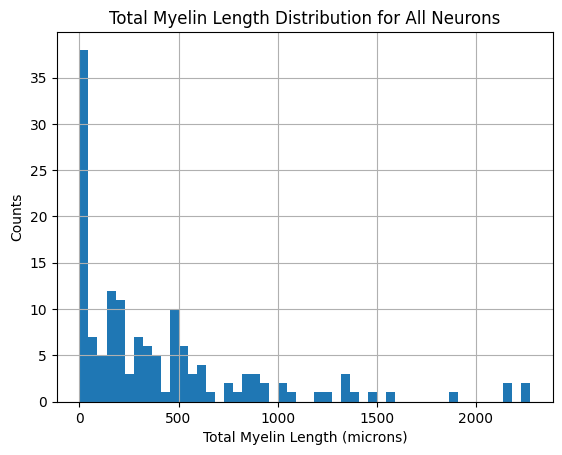

In [78]:
#Get distibution of myelin lengths for cell type '5P-IT' as histogram

cell_type = '23P'
# myelin_info_df[myelin_info_df['cell_type'] == cell_type]['total_myelin_length'].hist(bins=50)
myelin_info_df.hist(bins=50)
#print number of entries being binned
print(f"Number of {cell_type} neurons: ", len(myelin_info_df[myelin_info_df['cell_type'] == cell_type]))
plt.xlabel('Total Myelin Length (microns)')
plt.ylabel('Counts')
# plt.title(f'Total Myelin Length Distribution for Cell Type {cell_type}')
plt.title(f'Total Myelin Length Distribution for All Neurons')
plt.show()


/var/folders/qp/r9cmw1dn5sl3gwgf322l1ykr0000gn/T/ipykernel_89426/2059386117.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(cell_types))


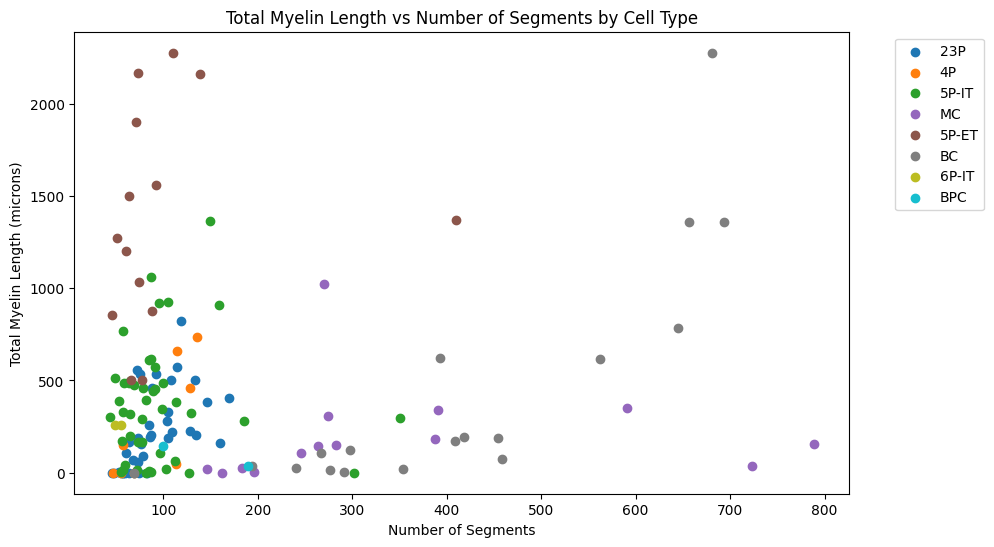

In [14]:
#plot total myelin length vs number of segments, but different colors for different cell types.
plt.figure(figsize=(10, 6))
cell_types = myelin_info_df['cell_type'].unique()
colors = plt.cm.get_cmap('tab10', len(cell_types))
for i, cell_type in enumerate(cell_types):
    subset = myelin_info_df[myelin_info_df['cell_type'] == cell_type]
    plt.scatter(subset['number_of_segments'], subset['total_myelin_length'], label=cell_type, color=colors(i))
plt.xlabel('Number of Segments')
plt.ylabel('Total Myelin Length (microns)')
plt.title('Total Myelin Length vs Number of Segments by Cell Type')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# #set xlims to 0 to 150
# plt.xlim(40, 200)

plt.show()

***LET'S DO SYNAPSE STUFF.***

In [ ]:
'''for each synapse, get pre_pt_position...
generate the axon_segments dictionary object
also, get the radii of the axons for each segment.
get cleaned axon segments

Now that we have all this,
We can do the following:
- get path_len_from_soma
- get vector_from_soma
- get post_cell_type
- get post_excit_inhib
- delay
- delay_unmyelin

'''

In [13]:
def get_delay_from_l_and_r(length, radius, myelin_status, k_myelinated = 6, k_unmyelinated = .3):
    #Get delay in ms from length and radius in microns.
    #radius in microns.
    #unmyelinated -> v = k_m * sqrt(d)    d in microns, v in m/s
    #myelinated -> v = k_u * d    d in microns, v in m/s
    d = 2 * radius
    if myelin_status == 1:
        v = k_myelinated * d  # in microns/us
    if myelin_status == 0:
        v = k_unmyelinated * np.sqrt(d) # in microns/us
    delay = length / v  # in us
    return delay / 1000  # convert to ms
    

In [55]:
#For pt_root_id, get synapses, skeleton, etc.

# pt_root_id = 864691135591041291 #23P
# pt_root_id = 864691135566237527 #23P
# pt_root_id = 864691136209328060 #23P
# pt_root_id = 864691136664845278 #23P
pt_root_id = 864691135274038801 #23P
# pt_root_id = 864691135479830982 #4P
# pt_root_id = 864691135476495936 #4P
# pt_root_id = 864691135082864887 #5P-IT
# pt_root_id = 864691135430356784 #5P-IT
# pt_root_id = 864691135866558078 #BC
# pt_root_id = 864691135725779883 #BC


#get synapses
output_syn_df = client.materialize.synapse_query(pre_ids=pt_root_id)
print(f"Number of synapses for {pt_root_id}: ", len(output_syn_df))
#get skeleton
sk_df = client.skeleton.get_skeleton(pt_root_id, output_format='swc')
sk_dict = client.skeleton.get_skeleton(pt_root_id, output_format='dict')
sk = Skeleton.from_dict(sk_dict)

#get myelin segments
with open(os.path.join(directory, f'{pt_root_id}.pkl'), 'rb') as f:
    segs = pickle.load(f)
segs = denoise_segs(segs)


Number of synapses for 864691135274038801:  796


In [56]:
#make segs_info dictionary

segs_info = {}
segs_info['path_length'] = []
segs_info['myelin_length'] = []
segs_info['delay'] = []
segs_info['delay_unmyel'] = []
segs_info['parent'] = []
segs_info['radius'] = []
segs_info['map_to_skel_segments'] = []
# segs_info['root'] = []

#map myelin segments (along axon) to skeleton segments (whole neuron)
parent_seg_skel = []
skel_to_axon_map = {}
axon_idx = 0
for i in range(len(sk.segments)):
    if sk_dict['compartment'][sk.segments[i][0]] == 2:  # Check if the segment is axon
        segs_info['map_to_skel_segments'].append(i)
        segs_info['radius'].append(sk_dict['radius'][sk.segments[i][0]] / 1000)  # Get radius of the first node in the segment

        #also get parent of last node - this will be the branch point, and start of parent segment
        last_pt = sk.segments[i][-1]
        temp_parent = sk.parent_nodes(last_pt)
        parent_seg_skel.append(sk.segment_map[temp_parent])
        skel_to_axon_map[i] = axon_idx
        axon_idx += 1

for i in range(len(parent_seg_skel)):
    if parent_seg_skel[i] not in skel_to_axon_map:
        segs_info['parent'].append(-1) #if parent not in axon segments, set to -1
    else:
        segs_info['parent'].append(skel_to_axon_map[parent_seg_skel[i]])
# segs_info['parent'] = [skel_to_axon_map[p] for p in parent_seg_skel if p in skel_to_axon_map]


for i in range(len(segs)):
    seg = segs[i]
    positions = np.array(seg['pt_position'])
    positions = positions * np.array([4, 4, 40]) / 1000 # Convert to microns
    myelin_flags = np.array(seg['myelin'])
    path_length = 0
    myelin_length = 0
    delay = 0
    delay_unmyel = 0

    #get path length of segment
    for j in range(len(positions) - 1):
        p1 = positions[j]
        p2 = positions[j + 1]
        length = np.linalg.norm(p2 - p1)
        #if myelinated, add to myelin length
        if myelin_flags[j] == 1 and myelin_flags[j + 1] == 1:
            myelin_length += length
        path_length += length
    #add length of last node to branch point to path length
    parent_seg = segs_info['parent'][i]
    if parent_seg != -1:
        #get position of branch point
        p1 = positions[-1]
        p2 = segs[parent_seg]['pt_position'][0] * np.array([4, 4, 40]) / 1000 # Convert to microns
        length = np.linalg.norm(p2 - p1)
        path_length += length
        if myelin_flags[-1] == 1 and segs[parent_seg]['myelin'][0] == 1: #but since branch point, this should not be reached.
            myelin_length += length

    
    #add to dict
    segs_info['path_length'].append(path_length)
    segs_info['myelin_length'].append(myelin_length)
    #get delay of segment
    radius = segs_info['radius'][i]

    delay = get_delay_from_l_and_r(path_length-myelin_length, radius, 0) + get_delay_from_l_and_r(myelin_length, radius, 1)
    delay_unmyel = get_delay_from_l_and_r(path_length, radius, 0)
    segs_info['delay'].append(delay)
    segs_info['delay_unmyel'].append(delay_unmyel)
        

In [57]:
#iterate through the synapses for the neuron.

synapses_len_delay_df = pd.DataFrame(columns=[
    'pre_pt_position', 'pre_pt_root_id', 'post_pt_root_id', 
    'post_cell_type', 'post_excit_inhib', 'size',
    'path_len_from_soma', 'vector_from_soma',
    'delay', 'delay_unmyelin'
])

for index, row in output_syn_df.iterrows():
    print(row['pre_pt_position'])
    #Get basic attributes
    syn_position = row['pre_pt_position']
    syn_position = np.array(syn_position) * np.array([4, 4, 40]) / 1000 # Convert to microns

    pre_pt_root_id = row['pre_pt_root_id']
    post_pt_root_id = row['post_pt_root_id']
    if len(cell_type_df[cell_type_df['pt_root_id'] == post_pt_root_id]) == 0:
        post_cell_type = 'unknown'
        post_excit_inhib = 'unknown'
    else:
        post_cell_type = cell_type_df[cell_type_df['pt_root_id'] == post_pt_root_id]['cell_type'].values[0]
        post_excit_inhib = cell_type_df[cell_type_df['pt_root_id'] == post_pt_root_id]['classification_system'].values[0]
    syn_size = row['size']

    #find index in segs that syn_position is closest to.
    closest_seg_idx = -1
    closest_pt_in_seg_idx = -1
    closest_dist = float('inf')
    for i in range(len(segs)):
        seg = segs[i]
        positions = np.array(seg['pt_position']) * np.array([4, 4, 40]) / 1000
        dists = np.linalg.norm(positions - syn_position, axis=1)
        #get min_dist and idx_min
        min_dist = np.min(dists)
        idx_min = np.argmin(dists)
        # min_dist = np.min(dists)
        if min_dist < closest_dist:
            closest_dist = min_dist
            closest_seg_idx = i
            closest_pt_in_seg_idx = idx_min
    
    #get length and delay from synapse to soma.
    path_len_from_soma = 0
    delay = 0
    delay_unmyel = 0

    #***** get path_length and myelin_length, delays for the portion of segment that synapse is on. *****
    #find for this segment.
    curr_seg = closest_seg_idx
    path_length = 0
    myelin_length = 0
    for j in range(closest_pt_in_seg_idx, len(segs[curr_seg]['pt_position']) - 1):
        p1 = segs[curr_seg]['pt_position'][j] * np.array([4, 4, 40]) / 1000
        p2 = segs[curr_seg]['pt_position'][j + 1] * np.array([4, 4, 40]) / 1000
        length = np.linalg.norm(p2 - p1)
        path_length += length
        if segs[curr_seg]['myelin'][j] == 1 and segs[curr_seg]['myelin'][j+1] == 1:
            myelin_length += length
    #Now add lengths to branch point.
    parent_seg = segs_info['parent'][curr_seg]
    if parent_seg != -1:
        #get position of branch point
        p1 = segs[curr_seg]['pt_position'][-1] * np.array([4, 4, 40]) / 1000
        p2 = segs[parent_seg]['pt_position'][0] * np.array([4, 4, 40]) / 1000 # Convert to microns
        length = np.linalg.norm(p2 - p1)
        path_length += length
        if segs[parent_seg]['myelin'][-1] == 1 and segs[parent_seg]['myelin'][0] == 1: #but since branch point, this should not be reached.
            myelin_length += length
    radius = segs_info['radius'][curr_seg]
    # if path_length - myelin_length < 0:
    #     print("Warning: path_length - myelin_length < 0")
    delay += get_delay_from_l_and_r(path_length-myelin_length, radius, 0) + get_delay_from_l_and_r(myelin_length, radius, 1)
    delay_unmyel += get_delay_from_l_and_r(path_length, radius, 0)
    # path_leng_from_soma += path_length

    #**** Get path length, delays for all parent segments up to soma. *****
    while parent_seg != -1:
        curr_seg = parent_seg
        path_length += segs_info['path_length'][curr_seg]
        delay += segs_info['delay'][curr_seg]
        delay_unmyel += segs_info['delay_unmyel'][curr_seg]
        parent_seg = segs_info['parent'][curr_seg]
        if parent_seg == -1:
            root_pt_position = segs[curr_seg]['pt_position'][0] * np.array([4, 4, 40]) / 1000
            vector_from_soma = syn_position - root_pt_position

    #add to dataframe
    synapses_len_delay_df = pd.concat([
        synapses_len_delay_df,
        pd.DataFrame([{
            'pre_pt_position': syn_position,
            'pre_pt_root_id': pre_pt_root_id,
            'post_pt_root_id': post_pt_root_id,
            'post_cell_type': post_cell_type,
            'post_excit_inhib': post_excit_inhib,
            'size': syn_size,
            'path_len_from_soma': path_length,
            'vector_from_soma': vector_from_soma,
            'delay': delay,
            'delay_unmyelin': delay_unmyel
        }])
    ], ignore_index=True)



[192042 154434  22150]
[286190 126264  26515]
[174418 125724  17261]
[291862 136156  21931]
[198968 156590  22250]
[292580 133678  22463]
[335506 118868  23608]
[284360 126716  27036]
[310810 129866  27263]
[160168 181666  18935]
[155664 153320  22116]
[343548 112274  23430]
[212462 194840  25900]
[205720 199512  24029]
[291056 126758  24471]
[194266 157580  18568]
[312404 136406  26730]
[212168 195068  25800]
[166782 178310  19341]
[329596 143594  26832]
[210018 223568  21395]
[313320 139046  25800]
[207234 106032  18053]
[193520 158884  18413]
[194756 156904  18815]
[345680 106694  23303]
[194484 156988  18855]
[199542 164494  19410]
[206782 217076  24607]
[322788 126408  26940]
[148576 152886  22345]
[322212 139630  24246]
[283668 143900  20995]
[209576 190664  18694]
[283800 129952  27075]
[200448 171672  17944]
[211518 126734  23792]
[216000 196486  25082]
[211446 131880  23517]
[190096 146588  22434]
[209240 112128  24514]
[211206 131984  23501]
[189400 139276  27201]
[218474 228

/var/folders/qp/r9cmw1dn5sl3gwgf322l1ykr0000gn/T/ipykernel_420/560213777.py:89: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  synapses_len_delay_df = pd.concat([


[196908 132094  21949]
[219566 195332  25568]
[207996 116480  17404]
[190894 137084  26909]
[229814 161042  15481]
[183352 177254  19829]
[222974 186916  26906]
[325322 153336  24617]
[299480 123976  21419]
[192430 160734  18245]
[210776 135902  23130]
[327264 115368  24281]
[292986 140254  24069]
[206822 105420  17789]
[328004 120602  24363]
[203248 209248  18659]
[191888 142838  23176]
[193968 158046  18517]
[251052 162012  20630]
[158448 182670  18836]
[205512 211000  24362]
[187506 175800  19870]
[174808 148574  18954]
[193538 158940  18401]
[205762 199452  23929]
[293560 126484  21460]
[245700 160906  20682]
[291504 148748  22519]
[197310 136600  21718]
[286372 135572  21099]
[191444 135218  26522]
[327394 132774  24506]
[187924 146450  24053]
[291516 127722  24186]
[229092 167968  15381]
[292466 127848  21553]
[189072 160106  21632]
[209380 192590  26909]
[190386 146838  22397]
[220986 193382  25749]
[302058 120950  21558]
[201380 179966  21824]
[194480 162426  22561]
[292096 127

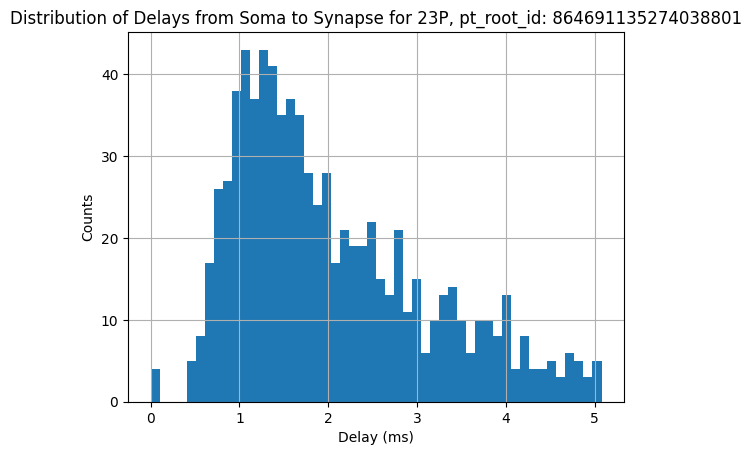

In [58]:
synapses_len_delay_df['delay'].hist(bins=50)
plt.xlabel('Delay (ms)')
plt.ylabel('Counts')
cell_type = cell_type_df[cell_type_df['pt_root_id'] == pt_root_id]['cell_type'].values[0]
plt.title(f'Distribution of Delays from Soma to Synapse for {cell_type}, pt_root_id: {pt_root_id}')
# plt.title('Distribution of Delays from Synapse to Soma')
plt.show()

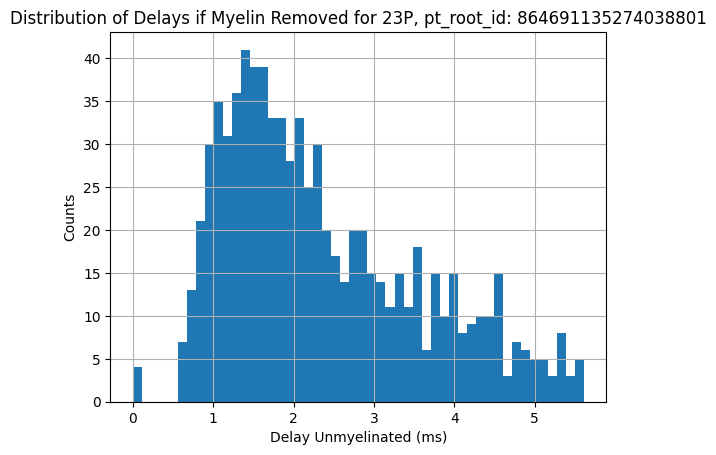

In [59]:
##plot distribution of delays_unmyl in synapses_len_delay_df

synapses_len_delay_df['delay_unmyelin'].hist(bins=50)
plt.xlabel('Delay Unmyelinated (ms)')
plt.ylabel('Counts')
# plt.title('Distribution of Delays if myelin were removed, ')
cell_type = cell_type_df[cell_type_df['pt_root_id'] == pt_root_id]['cell_type'].values[0]
plt.title(f'Distribution of Delays if Myelin Removed for {cell_type}, pt_root_id: {pt_root_id}')
plt.show()

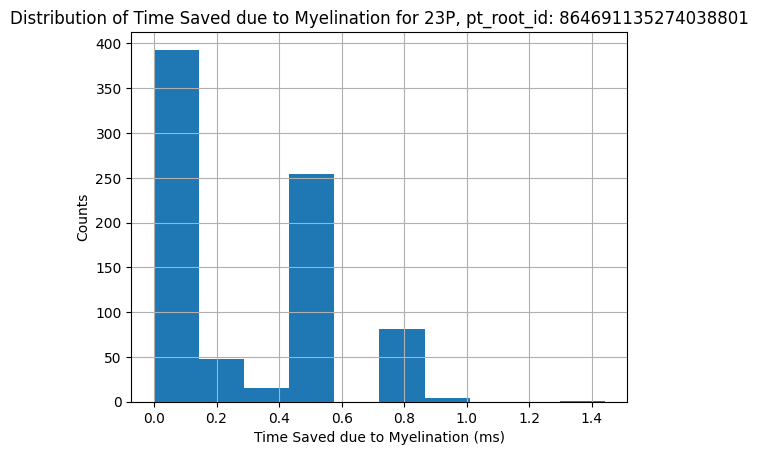

In [60]:
#plot histogram of time saved due to myelination, ie delay_unmyelin - delay (do it without adding to dataframe)
time_saved = synapses_len_delay_df['delay_unmyelin'] - synapses_len_delay_df['delay']
time_saved.hist(bins=10)
plt.xlabel('Time Saved due to Myelination (ms)')
plt.ylabel('Counts')
# plt.title('Distribution of Time Saved due to Myelination')
cell_type = cell_type_df[cell_type_df['pt_root_id'] == pt_root_id]['cell_type'].values[0]
plt.title(f'Distribution of Time Saved due to Myelination for {cell_type}, pt_root_id: {pt_root_id}')
plt.show()

In [64]:
#Let's look at counts of cell types in post_cell_type column
synapses_len_delay_df['post_cell_type'].value_counts()

post_cell_type
23P          188
unknown      188
4P           113
BC            95
MC            77
5P-ET         45
5P-IT         44
6P-IT         21
6P-CT         14
BPC            8
microglia      1
oligo          1
NGC            1
Name: count, dtype: int64

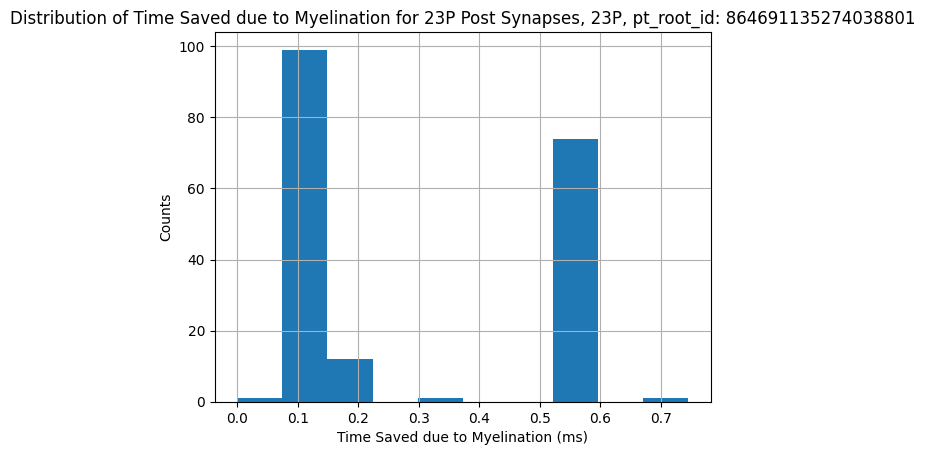

In [61]:
#Let's look at time saved for only 23P cell types
post_cell_type = '23P'
time_saved_23P = synapses_len_delay_df[synapses_len_delay_df['post_cell_type'] == post_cell_type]['delay_unmyelin'] - synapses_len_delay_df[synapses_len_delay_df['post_cell_type'] == post_cell_type]['delay']
time_saved_23P.hist(bins=10)
plt.xlabel('Time Saved due to Myelination (ms)')
plt.ylabel('Counts')
cell_type = cell_type_df[cell_type_df['pt_root_id'] == pt_root_id]['cell_type'].values[0]
plt.title(f'Distribution of Time Saved due to Myelination for {cell_type} Post Synapses, {post_cell_type}, pt_root_id: {pt_root_id}')
plt.show()

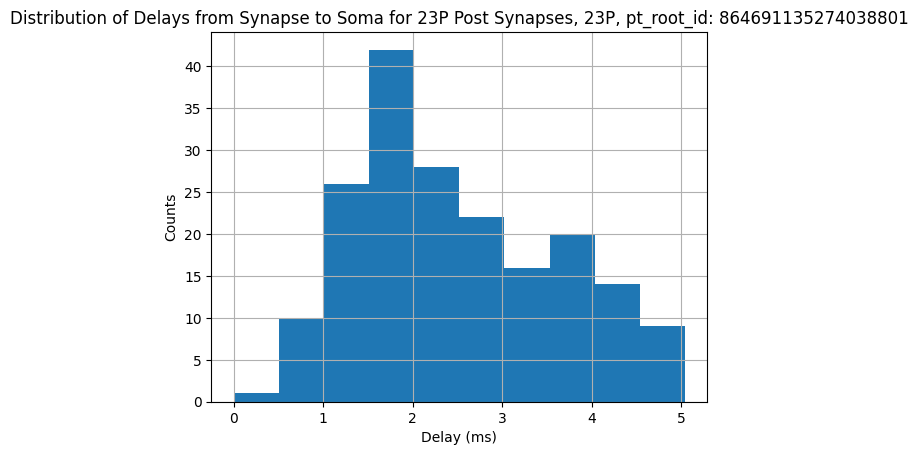

In [68]:
#Let's look at the delay distribution based on cell type of post synaptic neuron.
post_cell_type = '23P'
synapses_len_delay_df[synapses_len_delay_df['post_cell_type'] == post_cell_type]['delay'].hist(bins=10)
plt.xlabel('Delay (ms)')
plt.ylabel('Counts')
cell_type = cell_type_df[cell_type_df['pt_root_id'] == pt_root_id]['cell_type'].values[0]
plt.title(f'Distribution of Delays from Synapse to Soma for {cell_type} Post Synapses, {post_cell_type}, pt_root_id: {pt_root_id}')
plt.show()

BELOW IS FOR BASKET CELL AS EXAMPLE.

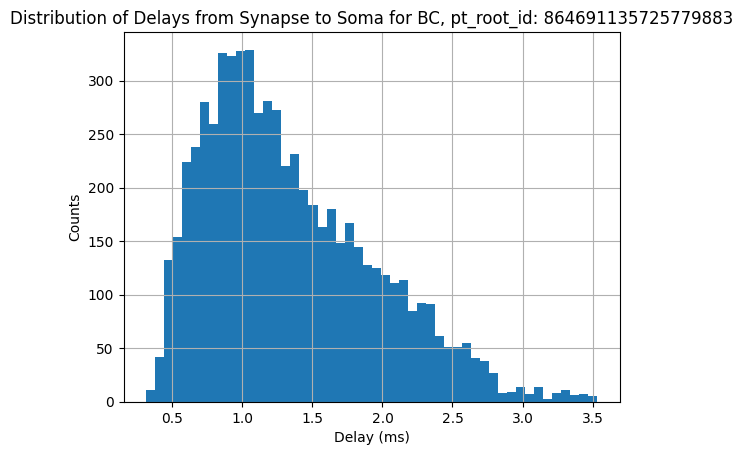

In [71]:
#plot distribution of delays in synapses_len_delay_df.
synapses_len_delay_df['delay'].hist(bins=50)
plt.xlabel('Delay (ms)')
plt.ylabel('Counts')
cell_type = cell_type_df[cell_type_df['pt_root_id'] == pt_root_id]['cell_type'].values[0]
plt.title(f'Distribution of Delays from Synapse to Soma for {cell_type}, pt_root_id: {pt_root_id}')
# plt.title('Distribution of Delays from Synapse to Soma')
plt.show()

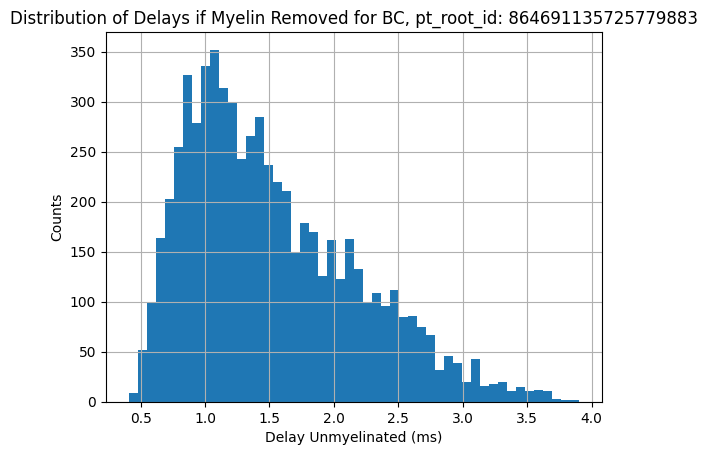

In [72]:
##plot distribution of delays_unmyl in synapses_len_delay_df

synapses_len_delay_df['delay_unmyelin'].hist(bins=50)
plt.xlabel('Delay Unmyelinated (ms)')
plt.ylabel('Counts')
# plt.title('Distribution of Delays if myelin were removed, ')
cell_type = cell_type_df[cell_type_df['pt_root_id'] == pt_root_id]['cell_type'].values[0]
plt.title(f'Distribution of Delays if Myelin Removed for {cell_type}, pt_root_id: {pt_root_id}')
plt.show()

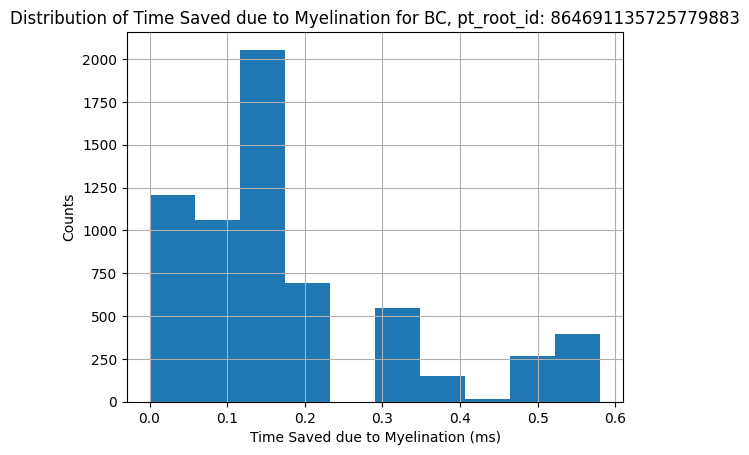

In [73]:
#plot histogram of time saved due to myelination, ie delay_unmyelin - delay (do it without adding to dataframe)
time_saved = synapses_len_delay_df['delay_unmyelin'] - synapses_len_delay_df['delay']
time_saved.hist(bins=10)
plt.xlabel('Time Saved due to Myelination (ms)')
plt.ylabel('Counts')
# plt.title('Distribution of Time Saved due to Myelination')
cell_type = cell_type_df[cell_type_df['pt_root_id'] == pt_root_id]['cell_type'].values[0]
plt.title(f'Distribution of Time Saved due to Myelination for {cell_type}, pt_root_id: {pt_root_id}')
plt.show()



**LET'S TRY THE ANALYSIS BASED ON IF NEURONS ARE OR ARE NOT IN COREGISTRATION TABLE**

In [127]:
tables = client.materialize.get_tables()
print(tables)

['baylor_gnn_cell_type_fine_model_v2', 'nucleus_alternative_points', 'allen_column_mtypes_v2', 'bodor_pt_cells', 'aibs_metamodel_mtypes_v661_v2', 'allen_v1_column_types_slanted_ref', 'aibs_column_nonneuronal_ref', 'nucleus_ref_neuron_svm', 'apl_functional_coreg_vess_fwd', 'vortex_compartment_targets', 'baylor_log_reg_cell_type_coarse_v1', 'gamlin_2023_mcs', 'l5et_column', 'pt_synapse_targets', 'coregistration_manual_v4', 'cg_cell_type_calls', 'synapses_pni_2', 'nucleus_detection_v0', 'vortex_manual_nodes_of_ranvier', 'bodor_pt_target_proofread', 'nucleus_functional_area_assignment', 'coregistration_auto_phase3_fwd_apl_vess_combined_v2', 'vortex_thalamic_proofreading_status', 'multi_input_spine_predictions_ssa', 'synapse_target_structure', 'proofreading_status_and_strategy', 'coregistration_auto_phase3_fwd_v2', 'vortex_peptidergic_proofreading_status', 'digital_twin_properties_bcm_coreg_v4', 'vortex_astrocyte_proofreading_status', 'digital_twin_properties_bcm_coreg_auto_phase3_fwd_v2', 

In [134]:
coreg_df = client.materialize.query_table('coregistration_manual_v4')


41
Number of neurons in coregistration:  41
Mean total myelin length for neurons in coregistration:  245.13658536585368
Median total myelin length for neurons in coregistration:  204.78
Number of neurons not in coregistration:  12
Mean total myelin length for neurons not in coregistration:  167.13083333333336
Median total myelin length for neurons not in coregistration:  30.294999999999998
T-statistic:  1.1232339423528475
P-value:  0.26659793592838577
U-statistic:  312.0
P-value (Mann-Whitney U test):  0.16071044966026737


/var/folders/qp/r9cmw1dn5sl3gwgf322l1ykr0000gn/T/ipykernel_89426/1647341195.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=['In Coregistration', 'Not in Coregistration'])


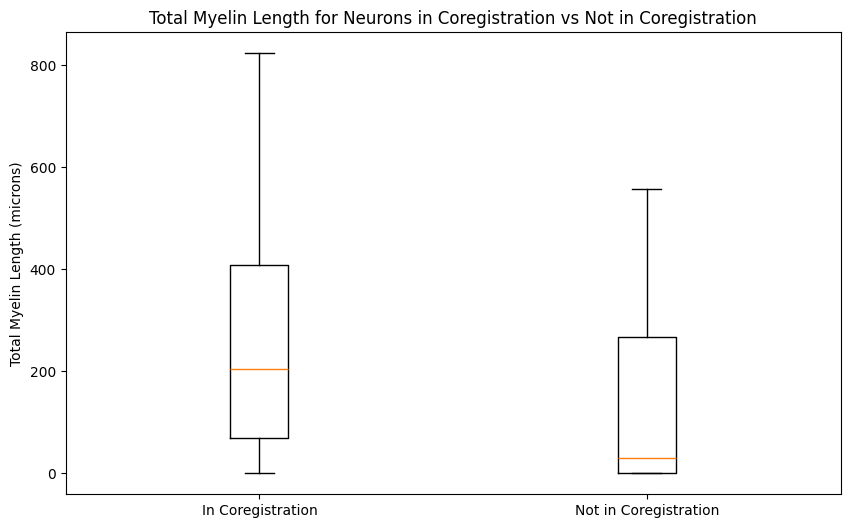

In [154]:
#get myelin_info_df where cell_type != BC or MC or BPC.

# myelin_info_df_exc = myelin_info_df[~myelin_info_df['cell_type'].isin(['BC', 'MC', 'BPC'])]

myelin_info_df_exc = myelin_info_df[myelin_info_df['cell_type'].isin(['23P'])]

#merge inner with coreg_df on pt_root_id

myelin_info_coreg = pd.merge(myelin_info_df_exc, coreg_df, left_on='pt_root_id', right_on='pt_root_id', how='inner')

print(len(myelin_info_coreg))

#Find all the neurons that are in myelin_info_df but not in coreg_df
myelin_info_not_coreg = myelin_info_df_exc[~myelin_info_df_exc['pt_root_id'].isin(coreg_df['pt_root_id'])]

#Make a numpy array of the total_myelin_length column for myelin_info_coreg and myelin_info_not_coreg
coreg_lengths = myelin_info_coreg['total_myelin_length'].to_list()
not_coreg_lengths = myelin_info_not_coreg['total_myelin_length'].to_list()
#print means of both also include n for each.
print("Number of neurons in coregistration: ", len(coreg_lengths))
print("Mean total myelin length for neurons in coregistration: ", np.mean(coreg_lengths))
print("Median total myelin length for neurons in coregistration: ", np.median(coreg_lengths))

print("Number of neurons not in coregistration: ", len(not_coreg_lengths))
print("Mean total myelin length for neurons not in coregistration: ", np.mean(not_coreg_lengths))
print("Median total myelin length for neurons not in coregistration: ", np.median(not_coreg_lengths))
#Do a basic t-test and get p-value
from scipy import stats
t_stat, p_value = stats.ttest_ind(coreg_lengths, not_coreg_lengths, equal_var=True)
print("T-statistic: ", t_stat)
print("P-value: ", p_value)

#do a mann whitney u test
u_stat, p_value_u = stats.mannwhitneyu(coreg_lengths, not_coreg_lengths, alternative='two-sided')
print("U-statistic: ", u_stat)
print("P-value (Mann-Whitney U test): ", p_value_u)

#plot value of total_myelin_length for myelin_info_coreg and myelin_info_not_coreg, to compare the amount. Maybe scatter the values with jitter, and make the means clear.
plt.figure(figsize=(10, 6))
data = [myelin_info_coreg['total_myelin_length'], myelin_info_not_coreg['total_myelin_length']]
plt.boxplot(data, labels=['In Coregistration', 'Not in Coregistration'])
plt.ylabel('Total Myelin Length (microns)')
plt.title('Total Myelin Length for Neurons in Coregistration vs Not in Coregistration')
plt.show()






In [155]:
#print fraction in coreg_lengths that are 0 and also fraction in not_coreg_lengths that are 0
num_zeros_coreg = sum(1 for length in coreg_lengths if length == 0)
num_zeros_not_coreg = sum(1 for length in not_coreg_lengths if length == 0)
print("Fraction of neurons with 0 myelin length in coregistration: ", num_zeros_coreg / len(coreg_lengths))
print("Fraction of neurons with 0 myelin length not in coregistration: ", num_zeros_not_coreg / len(not_coreg_lengths))

Fraction of neurons with 0 myelin length in coregistration:  0.1951219512195122
Fraction of neurons with 0 myelin length not in coregistration:  0.4166666666666667


/var/folders/qp/r9cmw1dn5sl3gwgf322l1ykr0000gn/T/ipykernel_89426/2231910829.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, patch_artist=True, boxprops=dict(alpha=0.4))


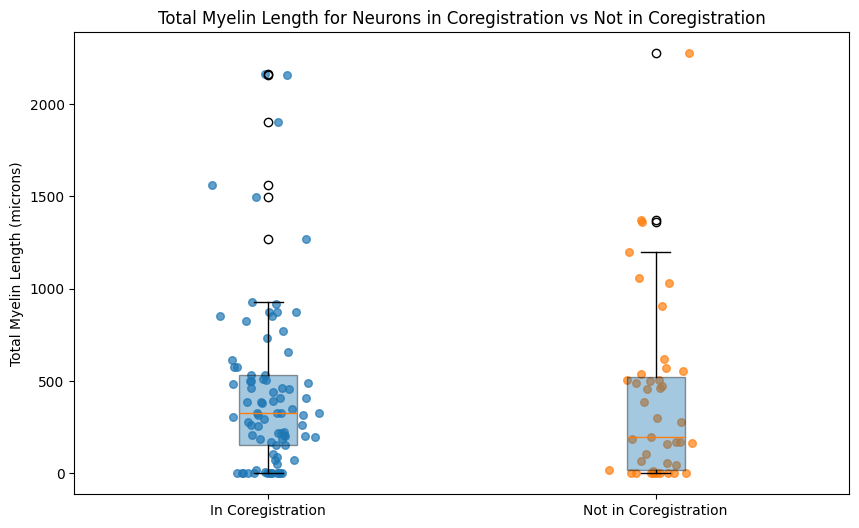

In [152]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))

# Collect data
data = [myelin_info_coreg['total_myelin_length'], 
        myelin_info_not_coreg['total_myelin_length']]

labels = ['In Coregistration', 'Not in Coregistration']

# Boxplot (optional, to give distribution summary)
plt.boxplot(data, labels=labels, patch_artist=True, boxprops=dict(alpha=0.4))

# Overlay jittered scatter points
for i, group in enumerate(data, start=1):
    x = np.random.normal(i, 0.05, size=len(group))  # jitter
    plt.scatter(x, group, alpha=0.7, s=30)

plt.ylabel('Total Myelin Length (microns)')
plt.title('Total Myelin Length for Neurons in Coregistration vs Not in Coregistration')
plt.show()


In [11]:
output_syn_df.head()

,id,created,superceded_id,valid,size,pre_pt_supervoxel_id,pre_pt_root_id,post_pt_supervoxel_id,post_pt_root_id,pre_pt_position,post_pt_position,ctr_pt_position
0,228711288,2020-11-04 06:48:58.343057+00:00,NaN,t,2984,95007425567978633,864691135566237527,95007425567972423,864691135182553602,"[220160, 132344, 16409]","[220142, 132326, 16398]","[220146, 132340, 16402]"
1,238504762,2020-11-04 06:49:11.545614+00:00,NaN,t,1796,95647753652383783,864691135566237527,95647753652374739,864691133785227531,"[224486, 185010, 16571]","[224396, 184962, 16562]","[224446, 184986, 16566]"
2,300434392,2020-11-04 06:49:11.962249+00:00,NaN,t,8228,100644140513443249,864691135566237527,100644140513437704,864691136005695178,"[260902, 186392, 15758]","[260908, 186456, 15756]","[260870, 186410, 15758]"
3,124826489,2020-11-04 06:49:11.490916+00:00,NaN,t,11620,86145293598843160,864691135566237527,86145293598834534,864691135441917512,"[155438, 164658, 20409]","[155538, 164602, 20399]","[155512, 164666, 20405]"
4,210272378,2020-11-04 06:53:26.252199+00:00,NaN,t,1292,93257347124156313,864691135566237527,93257347124148437,864691135569505260,"[207080, 200842, 20412]","[206964, 200788, 20409]","[207018, 200772, 20416]"


In [119]:
diff_my = sum(segs_info['delay']) - sum(segs_info['delay_unmyel'])

print(sum(segs_info['delay']))

print(sum(segs_info['path_length']))

print(np.mean(segs_info['radius'])*2) #mean diameter in microns

37.26227228600801
9819.804394051445
0.2952370450581052


In [107]:
print(segs_info['radius'][0])

128.14132368720882


In [74]:
# print(parent_seg_skel)
print(skel_to_axon_map)

{0: 0, 1: 1, 2: 2, 4: 3, 5: 4, 6: 5, 7: 6, 8: 7, 9: 8, 13: 9, 15: 10, 19: 11, 32: 12, 34: 13, 35: 14, 36: 15, 44: 16, 45: 17, 49: 18, 50: 19, 53: 20, 57: 21, 59: 22, 62: 23, 63: 24, 68: 25, 77: 26, 81: 27, 87: 28, 94: 29, 95: 30, 103: 31, 108: 32, 109: 33, 110: 34, 111: 35, 112: 36, 113: 37, 114: 38, 118: 39, 119: 40, 120: 41, 124: 42, 125: 43, 126: 44, 131: 45, 132: 46, 133: 47, 134: 48, 138: 49, 139: 50, 153: 51, 154: 52, 158: 53, 159: 54, 162: 55, 164: 56, 165: 57, 170: 58, 171: 59, 173: 60, 175: 61, 176: 62, 178: 63, 179: 64, 180: 65, 181: 66, 182: 67, 183: 68, 184: 69, 185: 70, 186: 71}


In [79]:
print(parent_seg_skel)

[np.int64(19), np.int64(50), np.int64(19), np.int64(7), np.int64(87), np.int64(154), np.int64(59), np.int64(7), np.int64(50), np.int64(113), np.int64(35), np.int64(94), np.int64(109), np.int64(53), np.int64(164), np.int64(35), np.int64(87), np.int64(49), np.int64(53), np.int64(159), np.int64(95), np.int64(113), np.int64(126), np.int64(59), np.int64(49), np.int64(81), np.int64(81), np.int64(124), np.int64(114), np.int64(110), np.int64(94), np.int64(95), np.int64(109), np.int64(110), np.int64(111), np.int64(187), np.int64(111), np.int64(133), np.int64(120), np.int64(109), np.int64(112), np.int64(112), np.int64(119), np.int64(114), np.int64(125), np.int64(124), np.int64(119), np.int64(120), np.int64(126), np.int64(133), np.int64(125), np.int64(138), np.int64(139), np.int64(138), np.int64(154), np.int64(139), np.int64(159), np.int64(164), np.int64(134), np.int64(134), np.int64(165), np.int64(179), np.int64(165), np.int64(158), np.int64(158), np.int64(179), np.int64(176), np.int64(176), np.

In [76]:
print(segs_info['parent'])

[11, 19, 11, 6, 28, 52, 22, 6, 19, 37, 14, 29, 33, 20, 56, 14, 28, 18, 20, 54, 30, 37, 44, 22, 18, 27, 27, 42, 38, 34, 29, 30, 33, 34, 35, 35, 47, 41, 33, 36, 36, 40, 38, 43, 42, 40, 41, 44, 47, 43, 49, 50, 49, 52, 50, 54, 56, 48, 48, 57, 64, 57, 53, 53, 64, 62, 62, 32, 32, 46, 46]


In [120]:
print(segs_info['delay'])
print(segs_info['delay_unmyel'])
# print(len(segs_info['parent']))
# print(len(segs))
# print(len(parent_seg_skel))

[np.float64(1.2546030830453319), np.float64(0.8470359793974341), np.float64(0.8209072316687961), np.float64(0.11652448755817324), np.float64(1.4896255282359223), np.float64(2.4813031429065044), np.float64(0.5832301378173785), np.float64(1.9449709084282398), np.float64(0.8904996791586067), np.float64(1.06972545885065), np.float64(0.5774942648628694), np.float64(0.3910138345900424), np.float64(1.1873651219495056), np.float64(0.8896930543233769), np.float64(0.633893129940399), np.float64(0.0618261026692163), np.float64(1.2595046932251663), np.float64(0.6353103552787722), np.float64(0.6701031292032403), np.float64(0.4547943855213399), np.float64(0.33423817074994305), np.float64(0.2748455928274037), np.float64(0.18601457943373223), np.float64(0.07929441129682303), np.float64(0.5289892212748979), np.float64(0.5727748188929486), np.float64(0.026943999670614095), np.float64(0.32768386389385606), np.float64(0.10174645358911268), np.float64(0.07058715632257735), np.float64(0.04121113775916942), 

In [46]:
print(sk.parent_nodes(sk.root))

# sk.segment_map[4]

-1


In [57]:
print(sk.root)
print(sk.segment_map[-1])

7388
187


In [40]:
sk_df.head()

,id,type,x,y,z,radius,parent
0,0,1,707.392,473.344,846.72,5.977,-1
1,1,2,708.744,483.168,844.36,0.261,0
2,2,2,709.224,485.248,843.80,0.261,1
3,3,2,709.496,487.032,843.80,0.261,2
4,4,2,709.920,489.152,843.96,0.261,3


In [53]:
print(sk.segments[187])
print((sk.vertices[7388] / np.array([4, 4, 40])).astype(int)) 

[7388]
[176848 118336  21168]
